https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fcode%2Falialmuhaysin%2Friyadh-villas-aqar-dataset-analysis-eda%2Finput

**BEGANING OF ANALYSIS**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Make plots look nicer
sns.set(style="whitegrid")
plt.style.use('ggplot')


In [ ]:
# Replace with your actual file name
df = pd.read_csv("/content/RiyadhVillasAqar.csv")

# Show the first few rows
df.head()


/tmp/ipython-input-22-2776493867.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/RiyadhVillasAqar.csv")


,Unnamed: 0,front,rooms,lounges,bathrooms,streetWidth,stairs,propertyAge,driverRoom,tent,...,apartments,maidRoom,elevator,furnihsed,pool,basement,neighbourhood,location,price,square price
0,0,شرقية,5,4.0,5+,20.0,1.0,0.0,1.0,1.0,...,0,0.0,0.0,0.0,0.0,0.0,عكاظ,جنوب الرياض,1050000.0,3500.000000
1,1,غربية,4,3.0,5+,20.0,1.0,0.0,1.0,1.0,...,2.0,1.0,1.0,0.0,0.0,0.0,المهدية,غرب الرياض,3000000.0,5555.555556
2,2,جنوبية شرقية,7,2.0,5+,15.0,1.0,31.0,1.0,0.0,...,0,1.0,0.0,0.0,0.0,0.0,الشفا,جنوب الرياض,2000000.0,2285.714286
3,3,غربية,7,3.0,5+,15.0,1.0,3.0,0.0,1.0,...,0,1.0,0.0,1.0,0.0,0.0,ظهرة لبن,غرب الرياض,894000.0,4470.000000
4,4,شمالية,4,2.0,4,25.0,1.0,0.0,1.0,1.0,...,3.0,1.0,1.0,1.0,0.0,0.0,قرطبة,شرق الرياض,3500000.0,8750.000000


In [ ]:
# Shape and structure
print("Shape:", df.shape)

Shape: (46826, 26)


In [ ]:
print("\nColumns:\n", df.columns)



Columns:
 Index(['Unnamed: 0', 'front', 'rooms', 'lounges', 'bathrooms', 'streetWidth',
       'stairs', 'propertyAge', 'driverRoom', 'tent', 'patio', 'kitchen',
       'outdoorRoom', 'garage', 'duplex', 'space', 'apartments', 'maidRoom',
       'elevator', 'furnihsed', 'pool', 'basement', 'neighbourhood',
       'location', 'price', 'square price'],
      dtype='object')


In [ ]:
print("\nData types:\n", df.dtypes)



Data types:
 Unnamed: 0         int64
front             object
rooms              int64
lounges           object
bathrooms         object
streetWidth      float64
stairs           float64
propertyAge      float64
driverRoom       float64
tent             float64
patio            float64
kitchen          float64
outdoorRoom      float64
garage           float64
duplex           float64
space              int64
apartments        object
maidRoom         float64
elevator         float64
furnihsed        float64
pool             float64
basement         float64
neighbourhood     object
location          object
price            float64
square price     float64
dtype: object


In [ ]:
# Example: Convert bathrooms and lounges to numeric
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df['lounges'] = pd.to_numeric(df['lounges'], errors='coerce')
df['apartments'] = pd.to_numeric(df['apartments'], errors='coerce')

df.drop(columns=['Unnamed: 0'], inplace=True)



In [ ]:
print("\nData types:\n", df.dtypes)


Data types:
 front             object
rooms              int64
lounges          float64
bathrooms        float64
streetWidth      float64
stairs           float64
propertyAge      float64
driverRoom       float64
tent             float64
patio            float64
kitchen          float64
outdoorRoom      float64
garage           float64
duplex           float64
space              int64
apartments       float64
maidRoom         float64
elevator         float64
furnihsed        float64
pool             float64
basement         float64
neighbourhood     object
location          object
price            float64
square price     float64
dtype: object


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].astype('float64')


In [ ]:
print("\nData types:\n", df.dtypes)


Data types:
 front             object
rooms            float64
lounges          float64
bathrooms        float64
streetWidth      float64
stairs           float64
propertyAge      float64
driverRoom       float64
tent             float64
patio            float64
kitchen          float64
outdoorRoom      float64
garage           float64
duplex           float64
space            float64
apartments       float64
maidRoom         float64
elevator         float64
furnihsed        float64
pool             float64
basement         float64
neighbourhood     object
location          object
price            float64
square price     float64
dtype: object


In [ ]:
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 front                0
rooms                0
lounges           1131
bathrooms        32371
streetWidth        190
stairs               0
propertyAge          0
driverRoom           0
tent                 0
patio                0
kitchen              0
outdoorRoom          0
garage               0
duplex               0
space                0
apartments           4
maidRoom             0
elevator             0
furnihsed            0
pool                 0
basement             0
neighbourhood        0
location             0
price                2
square price         2
dtype: int64


In [ ]:
print("Before dropping:", df.shape)


Before dropping: (46826, 25)


In [ ]:
# 1. Drop rows where price is missing (critical)
df = df.dropna(subset=['price'])

# 2. Fill lounges and streetWidth with median
df['lounges'] = df['lounges'].fillna(df['lounges'].median())
df['streetWidth'] = df['streetWidth'].fillna(df['streetWidth'].median())

# 3. If square price is still NaN (from dropped prices), recalculate it
# (only if it's calculated as price / space)
df['square price'] = df['price'] / df['space']

# 4. Final missing check
print("\n✅ Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Final shape
print("\n✅ Final cleaned dataset shape:", df.shape)




✅ Remaining missing values:
bathrooms     32371
apartments        4
dtype: int64

✅ Final cleaned dataset shape: (46824, 25)


/tmp/ipython-input-32-3454180106.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lounges'] = df['lounges'].fillna(df['lounges'].median())
/tmp/ipython-input-32-3454180106.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['streetWidth'] = df['streetWidth'].fillna(df['streetWidth'].median())
/tmp/ipython-input-32-3454180106.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [ ]:
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 front                0
rooms                0
lounges              0
bathrooms        32371
streetWidth          0
stairs               0
propertyAge          0
driverRoom           0
tent                 0
patio                0
kitchen              0
outdoorRoom          0
garage               0
duplex               0
space                0
apartments           4
maidRoom             0
elevator             0
furnihsed            0
pool                 0
basement             0
neighbourhood        0
location             0
price                0
square price         0
dtype: int64


In [ ]:
print(df['bathrooms'].value_counts(dropna=False))


bathrooms
NaN    32371
4.0     8780
3.0     4122
2.0     1227
1.0      324
Name: count, dtype: int64


In [ ]:
# 1. Fill bathrooms (70% missing) with median to preserve the feature
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

# 2. Fill small number of missing values in 'apartments'
df['apartments'] = df['apartments'].fillna(df['apartments'].median())

# 3. Final check
print("\n✅ Final missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Final shape
print("\n✅ Cleaned dataset shape:", df.shape)



✅ Final missing values:
Series([], dtype: int64)

✅ Cleaned dataset shape: (46824, 25)


/tmp/ipython-input-35-2846183535.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
/tmp/ipython-input-35-2846183535.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['apartments'] = df['apartments'].fillna(df['apartments'].median())


In [ ]:
print(df['bathrooms'].value_counts(dropna=False))

bathrooms
4.0    41151
3.0     4122
2.0     1227
1.0      324
Name: count, dtype: int64


In [ ]:
print("\nSummary statistics:\n", df.describe())


Summary statistics:
               rooms       lounges     bathrooms   streetWidth        stairs  \
count  46824.000000  46824.000000  46824.000000  46824.000000  46824.000000   
mean       4.687532      2.365838      3.838801     18.165919      0.684008   
std        1.104857      0.985242      0.478691      4.160333      0.464915   
min        1.000000      1.000000      1.000000      1.000000      0.000000   
25%        4.000000      2.000000      4.000000     15.000000      0.000000   
50%        5.000000      2.000000      4.000000     20.000000      1.000000   
75%        5.000000      3.000000      4.000000     20.000000      1.000000   
max        7.000000      5.000000      4.000000    100.000000      1.000000   

        propertyAge    driverRoom          tent         patio       kitchen  \
count  46824.000000  46824.000000  46824.000000  46824.000000  46824.000000   
mean       2.454895      0.355886      0.466257      0.769392      0.979113   
std        6.496952      0.47

In [ ]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 front            0
rooms            0
lounges          0
bathrooms        0
streetWidth      0
stairs           0
propertyAge      0
driverRoom       0
tent             0
patio            0
kitchen          0
outdoorRoom      0
garage           0
duplex           0
space            0
apartments       0
maidRoom         0
elevator         0
furnihsed        0
pool             0
basement         0
neighbourhood    0
location         0
price            0
square price     0
dtype: int64


In [ ]:
# Print missing counts per column
print("Missing values per column:\n", df.isnull().sum())

# Check if any missing value exists
print("\nAny missing values left?", df.isnull().values.any())

# Optionally, see total rows and compare with non-null counts
print("\nDataFrame info:")
df.info()


Missing values per column:
 front            0
rooms            0
lounges          0
bathrooms        0
streetWidth      0
stairs           0
propertyAge      0
driverRoom       0
tent             0
patio            0
kitchen          0
outdoorRoom      0
garage           0
duplex           0
space            0
apartments       0
maidRoom         0
elevator         0
furnihsed        0
pool             0
basement         0
neighbourhood    0
location         0
price            0
square price     0
dtype: int64

Any missing values left? False

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 46824 entries, 0 to 46825
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   front          46824 non-null  object 
 1   rooms          46824 non-null  float64
 2   lounges        46824 non-null  float64
 3   bathrooms      46824 non-null  float64
 4   streetWidth    46824 non-null  float64
 5   stairs         468

In [ ]:
df.shape

(46824, 25)

***now we finish of missing values ***

here start with outlyiers

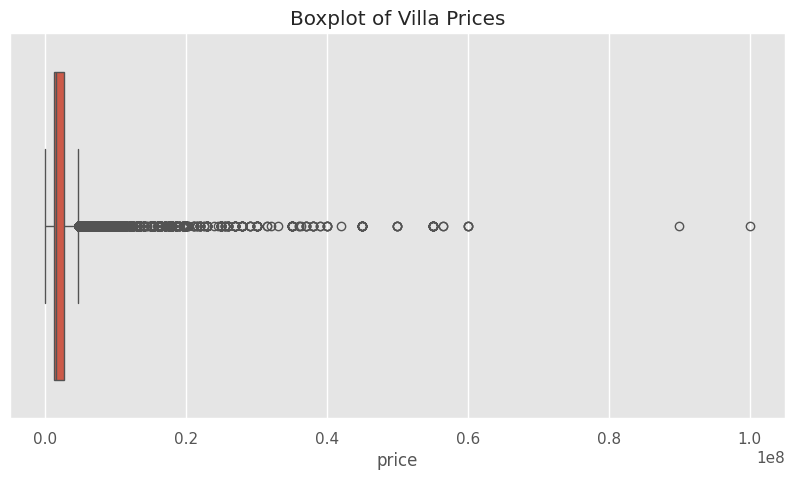

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Villa Prices')
plt.show()


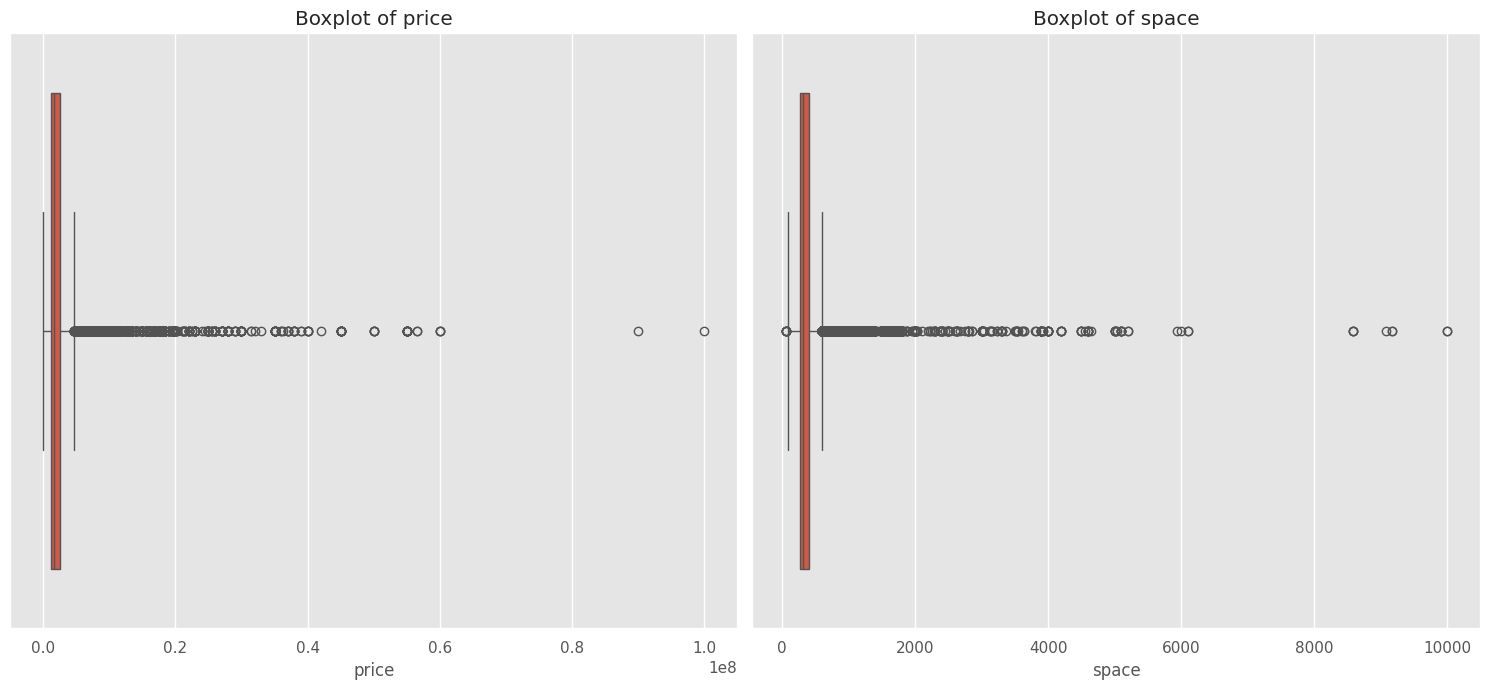

In [ ]:
numeric_cols = ['price', 'space']

plt.figure(figsize=(15,7))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


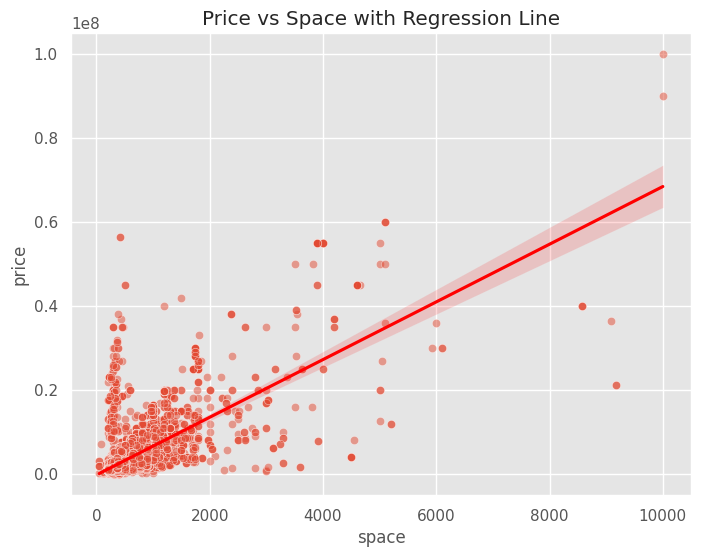

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='space', y='price', alpha=0.5)
sns.regplot(data=df, x='space', y='price', scatter=False, color='red')
plt.title("Price vs Space with Regression Line")
plt.show()



Outliers in 'space':
 - Q1: 270.0
 - Q3: 400.0
 - IQR: 130.0
 - Lower Bound: 75.0
 - Upper Bound: 595.0
 - Removed 4177 rows from 'space'

Outliers in 'price':
 - Q1: 1150000.0
 - Q3: 2300000.0
 - IQR: 1150000.0
 - Lower Bound: -575000.0
 - Upper Bound: 4025000.0
 - Removed 2495 rows from 'price'


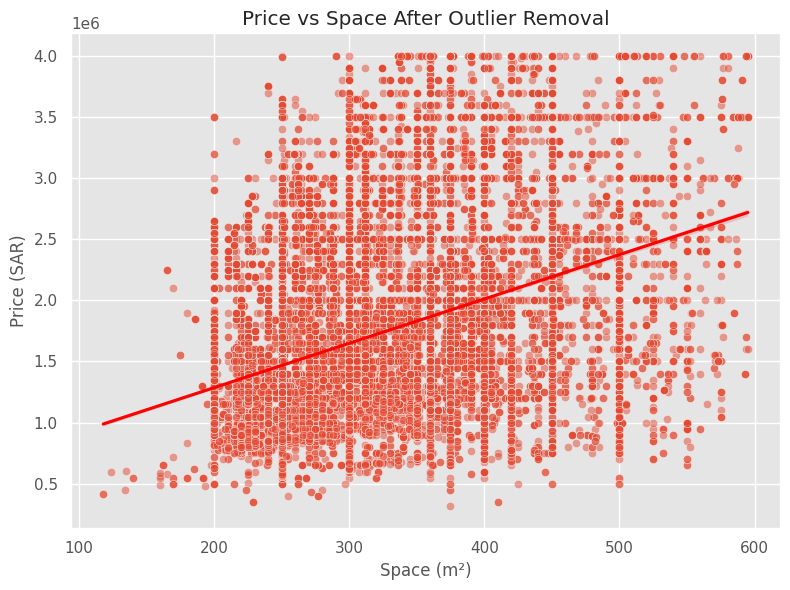

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define function to apply IQR filtering
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nOutliers in '{column}':")
    print(f" - Q1: {Q1}")
    print(f" - Q3: {Q3}")
    print(f" - IQR: {IQR}")
    print(f" - Lower Bound: {lower_bound}")
    print(f" - Upper Bound: {upper_bound}")

    before = df.shape[0]
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    after = df_filtered.shape[0]
    print(f" - Removed {before - after} rows from '{column}'")

    return df_filtered

# Step 2: Clean space first, then price (to avoid chaining problems)
df = remove_outliers_iqr(df, 'space')
df = remove_outliers_iqr(df, 'price')

# Remove suspiciously low-priced entries (e.g., below 100,000 SAR)
df = df[df['price'] > 300_000]


# Step 3: Optional - Plot clean scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='space', y='price', alpha=0.5)
sns.regplot(data=df, x='space', y='price', scatter=False, color='red')
plt.title("Price vs Space After Outlier Removal")
plt.xlabel("Space (m²)")
plt.ylabel("Price (SAR)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df.shape

(40100, 25)

In [ ]:
# Basic descriptive stats
print("📊 Descriptive Statistics:")
print(df[['price', 'space']].describe())



📊 Descriptive Statistics:
              price         space
count  4.010000e+04  40100.000000
mean   1.711294e+06    317.290823
std    7.638068e+05     76.136946
min    3.200000e+05    118.000000
25%    1.150000e+06    260.000000
50%    1.450000e+06    300.000000
75%    2.200000e+06    360.000000
max    4.000000e+06    595.000000


📊 Property Age Summary:
count    40100.000000
mean         1.667032
std          5.211969
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         35.000000
Name: propertyAge, dtype: float64


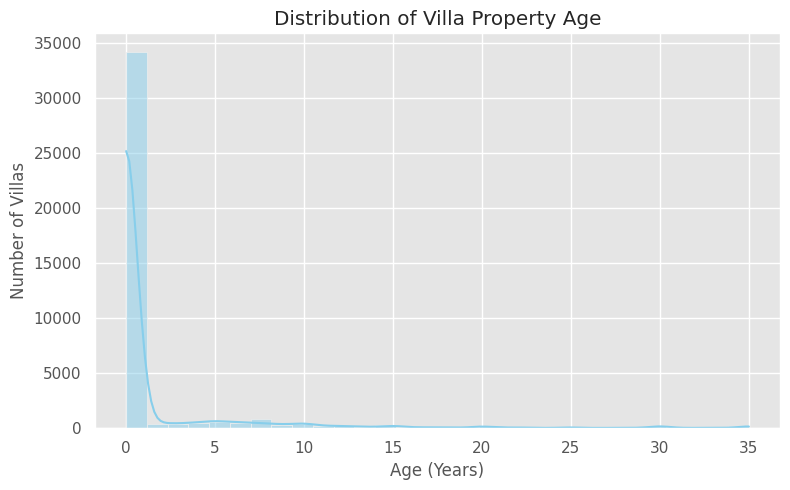

In [ ]:
# Summary statistics of age
print("📊 Property Age Summary:")
print(df['propertyAge'].describe())

# Plot the distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['propertyAge'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Villa Property Age")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Villas")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Filter villas that are 15 years old or newer
df = df[df['propertyAge'] <= 3]

# Confirm result
print("\n✅ Remaining villas after filtering by age ≤ 3 years:", df.shape[0])



✅ Remaining villas after filtering by age ≤ 3 years: 34914


📊 Property Age Summary:
count    34914.000000
mean         0.067280
std          0.386929
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: propertyAge, dtype: float64


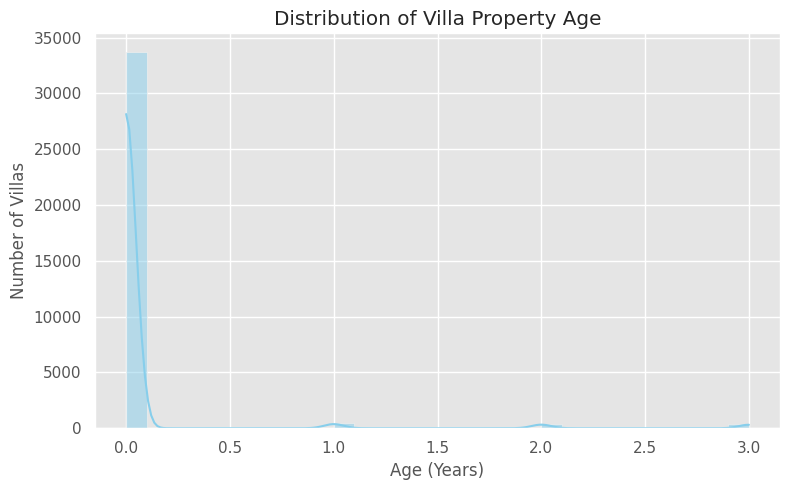

In [ ]:
# Summary statistics of age
print("📊 Property Age Summary:")
print(df['propertyAge'].describe())

# Plot the distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['propertyAge'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Villa Property Age")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Villas")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(df[['price', 'space', 'propertyAge']].describe())


              price         space   propertyAge
count  3.491400e+04  34914.000000  34914.000000
mean   1.663209e+06    306.092943      0.067280
std    7.427243e+05     67.442540      0.386929
min    3.500000e+05    118.000000      0.000000
25%    1.100000e+06    250.000000      0.000000
50%    1.400000e+06    300.000000      0.000000
75%    2.100000e+06    350.000000      0.000000
max    4.000000e+06    595.000000      3.000000


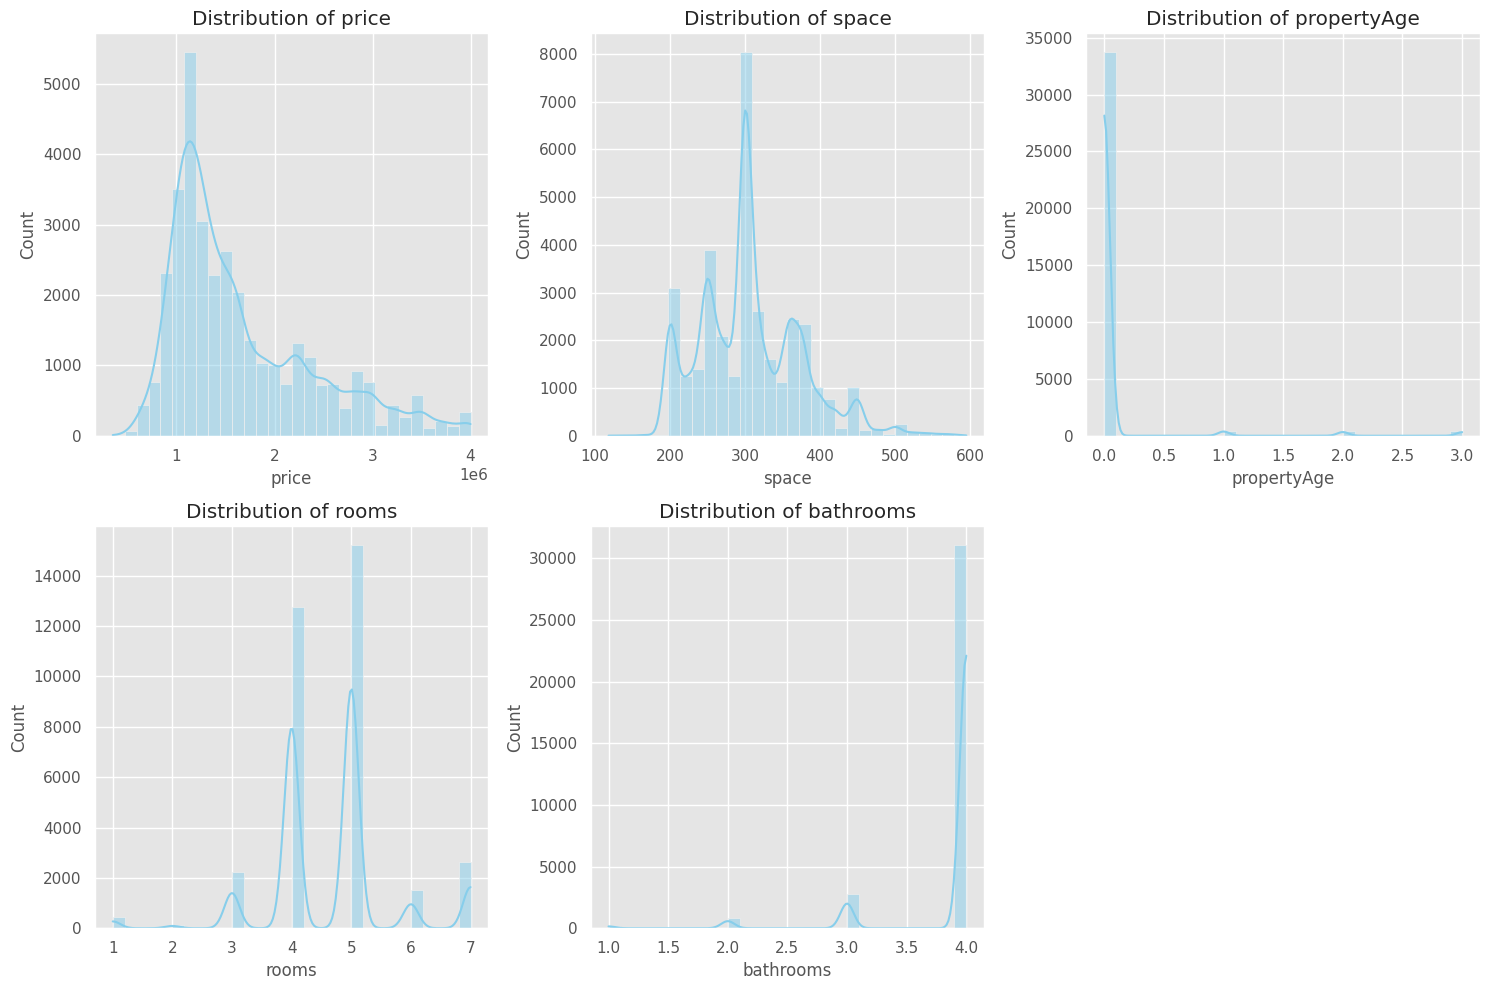

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_features = ['price', 'space', 'propertyAge', 'rooms', 'bathrooms']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


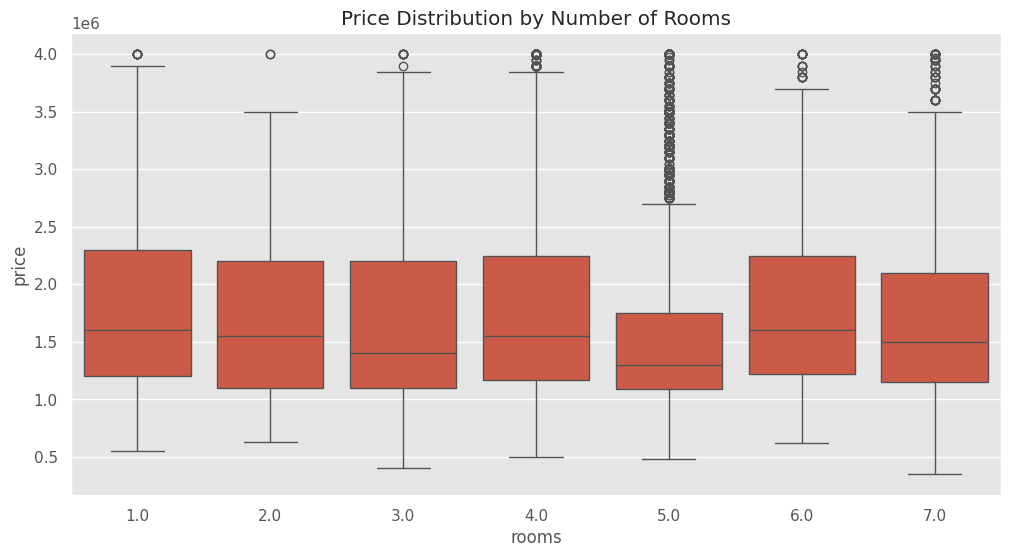

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='rooms', y='price', data=df)
plt.title('Price Distribution by Number of Rooms')
plt.show()


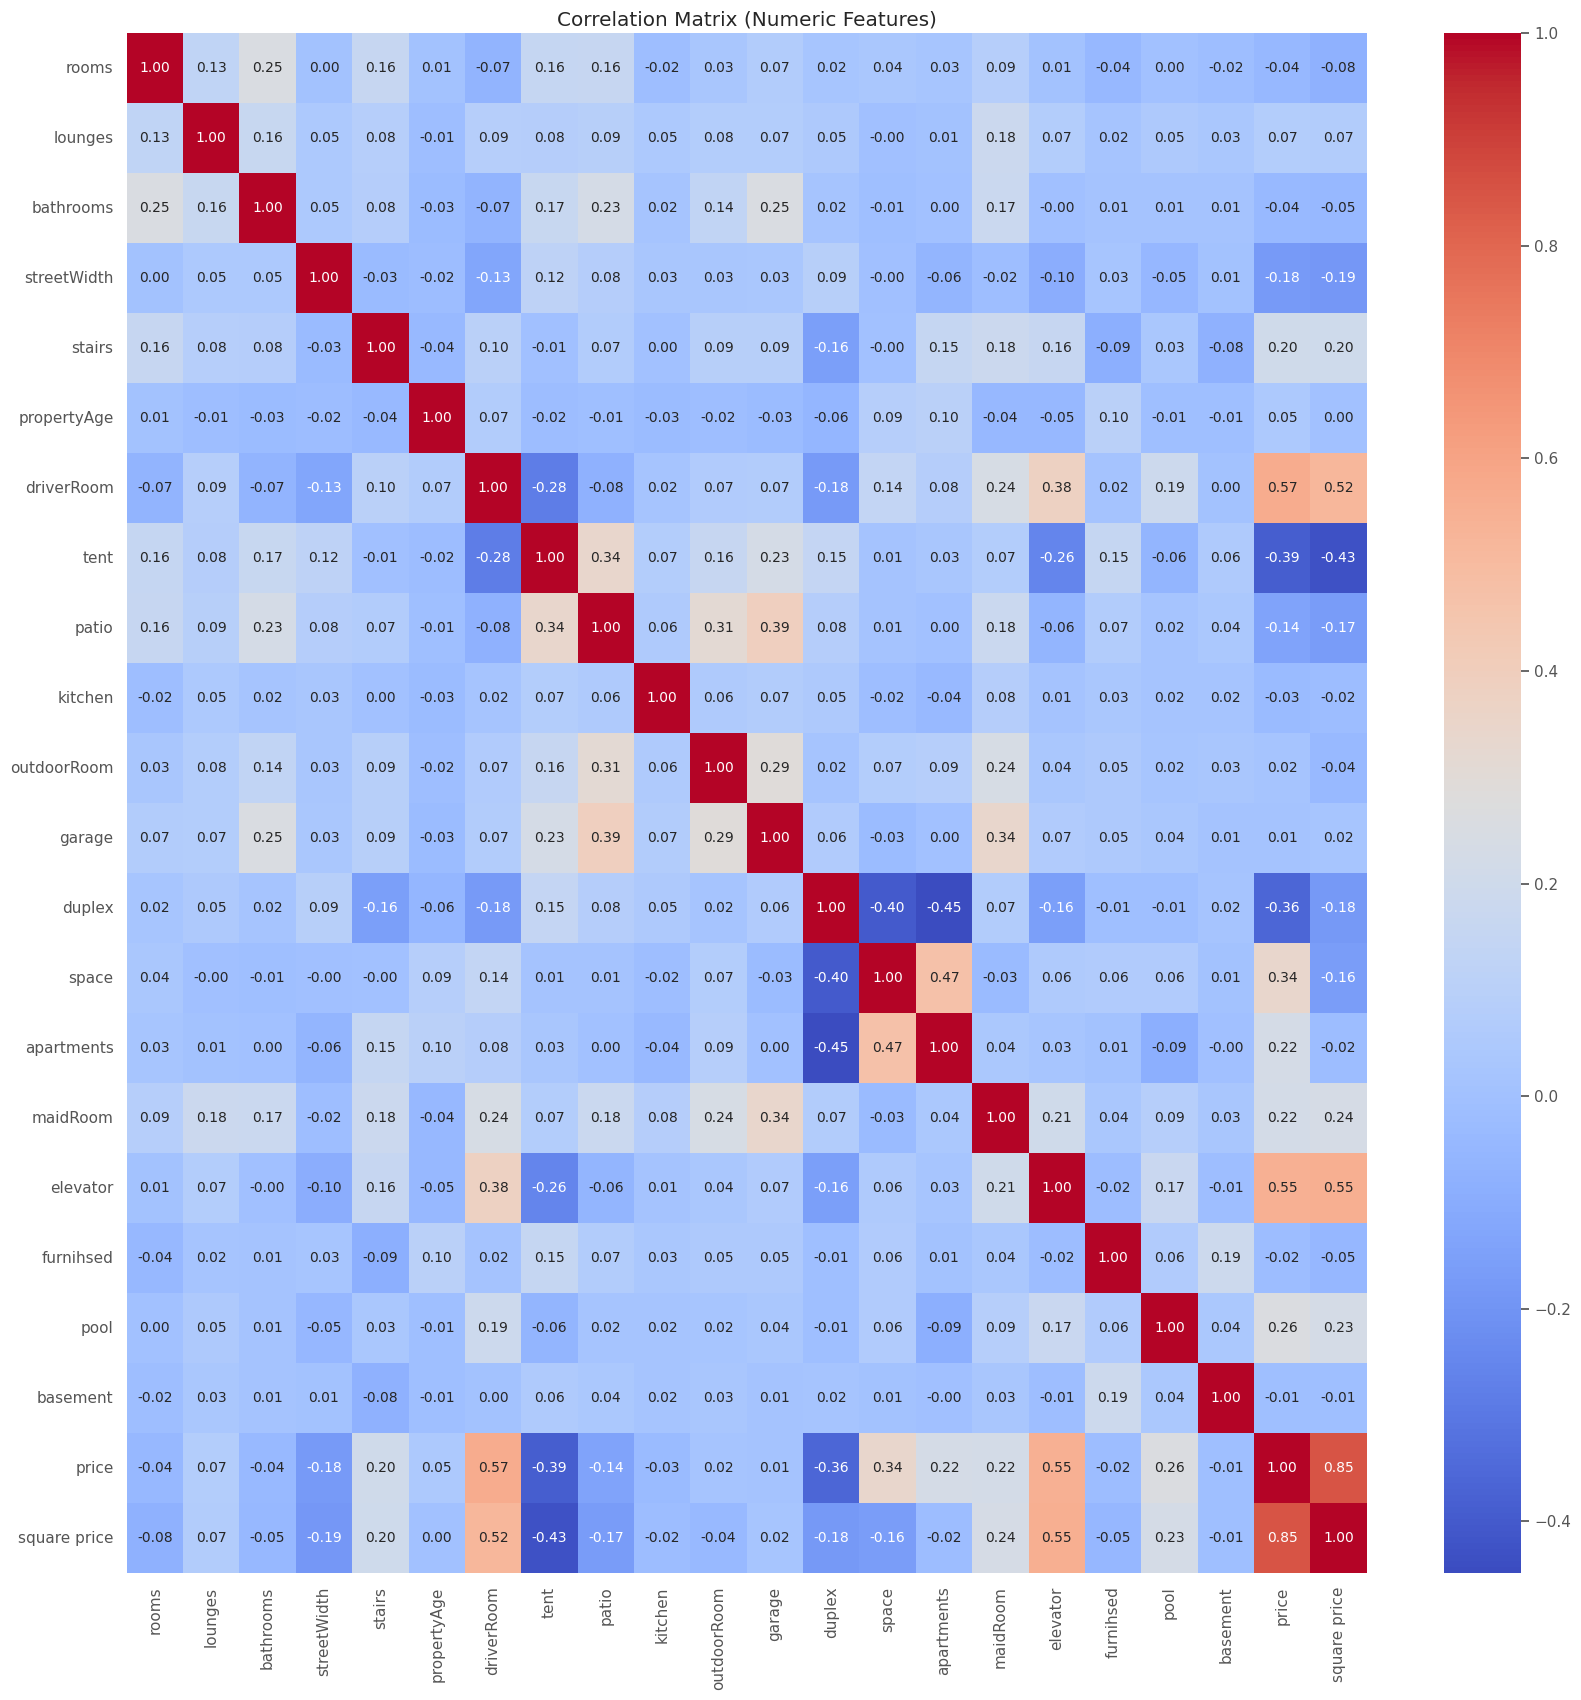

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(20, 20))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix (Numeric Features)')
plt.show()

In [ ]:
import pandas as pd

# Select categorical columns (usually object or category dtype)
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Categorical columns found: {list(cat_cols)}\n")

for col in cat_cols:
    print(f"Column: {col}")
    print(f" - Number of unique values: {df[col].nunique()}")
    print(f" - Missing values count: {df[col].isnull().sum()}")
    print(" - Value counts:")
    print(df[col].value_counts(dropna=False))
    print("="*50)


Categorical columns found: ['front', 'neighbourhood', 'location']

Column: front
 - Number of unique values: 10
 - Missing values count: 0
 - Value counts:
front
شمالية          9370
شرقية           8725
جنوبية          7631
غربية           5319
شمالية شرقية    1263
جنوبية شرقية     867
جنوبية غربية     858
شمالية غربية     815
ثلاث شوارع        57
أربع شوارع         9
Name: count, dtype: int64
Column: neighbourhood
 - Number of unique values: 232
 - Missing values count: 0
 - Value counts:
neighbourhood
 طويق                7127
 الرمال              3716
 عكاظ                3168
 بدر                 2582
 النرجس              2332
                     ... 
 الربيع الشرقي ٢        1
م الصديقي               1
 التقوى                 1
اص                      1
وس                      1
Name: count, Length: 232, dtype: int64
Column: location
 - Number of unique values: 5
 - Missing values count: 0
 - Value counts:
location
غرب الرياض     11983
شرق الرياض      8987
جنوب الرياض     8291
شم

In [ ]:
# 1. حذف الفئات النادرة في 'front'
front_to_remove = ['ثلاث شوارع', 'أربع شوارع']
df = df[~df['front'].isin(front_to_remove)]

print(f"بعد حذف الفئات النادرة في 'front'، عدد الصفوف: {df.shape[0]}")

# 2. طباعة معلومات مفصلة عن 'neighbourhood'
print("\nمعلومات عن عمود 'neighbourhood':")
print(f"عدد الأحياء الفريدة: {df['neighbourhood'].nunique()}")
print("أعلى 20 حي من حيث عدد الفلل:")
print(df['neighbourhood'].value_counts().head(20))

# 3. حذف فئة 'وسط الرياض' من 'location'
df = df[df['location'] != 'وسط الرياض']
print(f"\nبعد حذف 'وسط الرياض' من 'location'، عدد الصفوف: {df.shape[0]}")


بعد حذف الفئات النادرة في 'front'، عدد الصفوف: 34848

معلومات عن عمود 'neighbourhood':
عدد الأحياء الفريدة: 229
أعلى 20 حي من حيث عدد الفلل:
neighbourhood
طويق                       7120
الرمال                     3709
عكاظ                       3161
بدر                        2582
النرجس                     2328
العارض                     2006
المونسية                   1554
المهدية                    1300
الحزم                      1131
طيبة                        781
النهضة                      697
الدار البيضاء               652
ظهرة لبن                    607
العزيزية                    503
القادسية                    491
مطار الملك خالد الدولي      384
الياسمين                    367
ديراب                       355
الجنادرية                   327
السويدي                     287
Name: count, dtype: int64

بعد حذف 'وسط الرياض' من 'location'، عدد الصفوف: 34804


In [ ]:
# نستخدم groupby للحصول على عدد الفلل في كل حي داخل كل منطقة
neigh_counts = df.groupby(['location', 'neighbourhood']).size().reset_index(name='villa_count')

# ترتيب النتائج داخل كل location من الأكثر إلى الأقل
top_neighs_per_location = neigh_counts.sort_values(['location', 'villa_count'], ascending=[True, False])

# طباعة أفضل 20 أحياء في كل منطقة
for location in top_neighs_per_location['location'].unique():
    print(f"\n🔸 أفضل 20 أحياء في {location}:")
    top20 = top_neighs_per_location[top_neighs_per_location['location'] == location].head(20)
    print(top20[['neighbourhood', 'villa_count']].to_string(index=False))




🔸 أفضل 20 أحياء في جنوب الرياض:
  neighbourhood  villa_count
          عكاظ          3158
           بدر          2582
          طيبة           781
 الدار البيضاء           652
      العزيزية           502
         الشفا           285
        م قاضي            45
           أحد            43
            بدر           38
           احد            24
        المروة            23
          عريض            13
     ى الذماري            12
     المنصورية            11
           عكاظ           11
     م الحريمي            10
      ي بن عدي            10
         الحزم             8
       المصانع             8
       الاسكان             7

🔸 أفضل 20 أحياء في شرق الرياض:
           neighbourhood  villa_count
                 الرمال          3706
               المونسية          1554
                 النهضة           697
               القادسية           491
              الجنادرية           327
                  الرمال          278
 مطار الملك خالد الدولي           276
                  قرطب

In [ ]:
# نحسب عدد الفلل في كل حي داخل كل منطقة
neigh_counts = df.groupby(['location', 'neighbourhood']).size().reset_index(name='villa_count')

# ننشئ قائمة لتخزين أفضل 20 حي في كل منطقة
top_neighs_list = []

# لكل منطقة، نحصل على أفضل 20 حي ونضيفهم للقائمة
for location in neigh_counts['location'].unique():
    top20 = neigh_counts[neigh_counts['location'] == location] \
            .sort_values('villa_count', ascending=False) \
            .head(20)['neighbourhood'].tolist()
    top_neighs_list.extend(top20)

# نصفي البيانات الأصلية ونحتفظ فقط بالأحياء الموجودة في القائمة
df = df[df['neighbourhood'].isin(top_neighs_list)]

# نطبع عدد الصفوف المتبقية بعد التصفية
print(f"✅ عدد الصفوف بعد الاحتفاظ بأفضل 20 حي في كل منطقة: {df.shape[0]}")


✅ عدد الصفوف بعد الاحتفاظ بأفضل 20 حي في كل منطقة: 34158


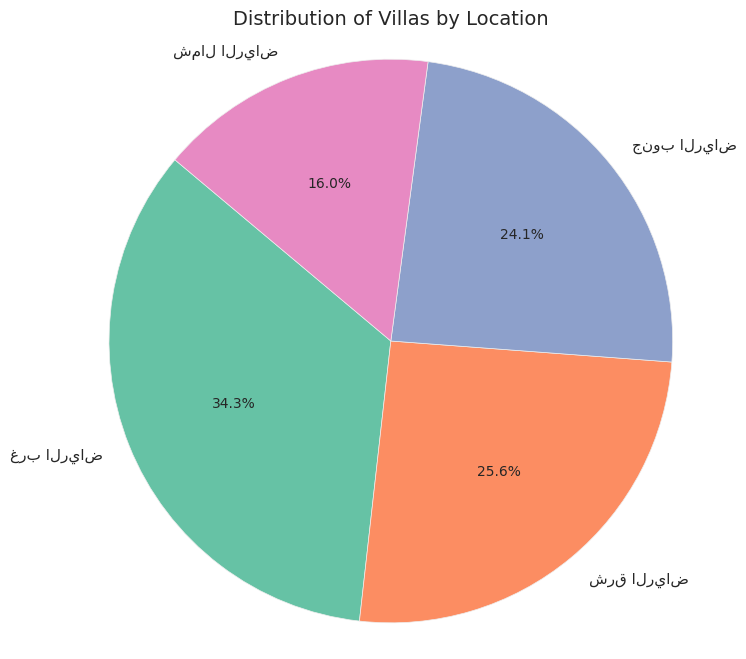

In [ ]:
import matplotlib.pyplot as plt

# حساب عدد الفلل في كل منطقة
location_counts = df['location'].value_counts()

# رسم الدائرة
plt.figure(figsize=(8, 8))
plt.pie(
    location_counts,
    labels=location_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set2.colors
)

plt.title("Distribution of Villas by Location", fontsize=14)
plt.axis('equal')  # يجعل الشكل دائري 100%
plt.show()


In [ ]:
# نحسب عدد الأحياء الفريدة في كل منطقة
neighbourhood_per_location = df.groupby('location')['neighbourhood'].nunique()

# عرض النتائج
print("عدد الأحياء في كل منطقة:\n")
print(neighbourhood_per_location)


عدد الأحياء في كل منطقة:

location
جنوب الرياض    21
شرق الرياض     21
شمال الرياض    23
غرب الرياض     21
Name: neighbourhood, dtype: int64


In [ ]:
# حساب عدد الأحياء الفريدة (unique)
total_neighbourhoods = df['neighbourhood'].nunique()

print(f"✅ مجمل عدد الأحياء في البيانات الحالية: {total_neighbourhoods}")


✅ مجمل عدد الأحياء في البيانات الحالية: 78


In [ ]:
# One-Hot Encoding على أعمدة location و front
df_encoded = pd.get_dummies(df, columns=['location', 'front'], prefix=['loc', 'front'], drop_first=False)

# عرض شكل البيانات بعد الترميز
print("✅ شكل البيانات بعد One-Hot Encoding:")
print(df_encoded.head())


✅ شكل البيانات بعد One-Hot Encoding:
   rooms  lounges  bathrooms  streetWidth  stairs  propertyAge  driverRoom  \
0    5.0      4.0        4.0         20.0     1.0          0.0         1.0   
1    4.0      3.0        4.0         20.0     1.0          0.0         1.0   
3    7.0      3.0        4.0         15.0     1.0          3.0         0.0   
4    4.0      2.0        4.0         25.0     1.0          0.0         1.0   
5    7.0      2.0        4.0         10.0     1.0          0.0         0.0   

   tent  patio  kitchen  ...  loc_شمال الرياض  loc_غرب الرياض  front_جنوبية  \
0   1.0    1.0      1.0  ...            False           False         False   
1   1.0    1.0      1.0  ...            False            True         False   
3   1.0    1.0      1.0  ...            False            True         False   
4   1.0    1.0      1.0  ...            False           False         False   
5   1.0    1.0      1.0  ...            False            True         False   

   front_جنوبية شرق

In [ ]:
df_encoded.head()

,rooms,lounges,bathrooms,streetWidth,stairs,propertyAge,driverRoom,tent,patio,kitchen,...,loc_شمال الرياض,loc_غرب الرياض,front_جنوبية,front_جنوبية شرقية,front_جنوبية غربية,front_شرقية,front_شمالية,front_شمالية شرقية,front_شمالية غربية,front_غربية
0,5.0,4.0,4.0,20.0,1.0,0.0,1.0,1.0,1.0,1.0,...,False,False,False,False,False,True,False,False,False,False
1,4.0,3.0,4.0,20.0,1.0,0.0,1.0,1.0,1.0,1.0,...,False,True,False,False,False,False,False,False,False,True
3,7.0,3.0,4.0,15.0,1.0,3.0,0.0,1.0,1.0,1.0,...,False,True,False,False,False,False,False,False,False,True
4,4.0,2.0,4.0,25.0,1.0,0.0,1.0,1.0,1.0,1.0,...,False,False,False,False,False,False,True,False,False,False
5,7.0,2.0,4.0,10.0,1.0,0.0,0.0,1.0,1.0,1.0,...,False,True,False,False,False,False,False,True,False,False


In [ ]:
import numpy as np
from sklearn.model_selection import KFold

# Reset the index of the DataFrame after filtering
df_encoded = df_encoded.reset_index(drop=True)

# نسخة من الداتا الأصلية حتى لا نعدل df مباشرة
df_encoded['neighbourhood_te'] = np.nan

# إنشاء KFold لتقسيم البيانات
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# تطبيق Target Encoding لكل fold
for train_index, val_index in kf.split(df):
    train_data = df.iloc[train_index]
    val_data = df.iloc[val_index]

    means = train_data.groupby('neighbourhood')['price'].mean()
    df.loc[val_index, 'neighbourhood_te'] = val_data['neighbourhood'].map(means)

# ملء القيم الناقصة بالمتوسط العام
global_mean = df['price'].mean()
df['neighbourhood_te'] = df['neighbourhood_te'].fillna(global_mean)

In [ ]:
df_encoded = pd.get_dummies(df, columns=['location', 'front'], prefix=['loc', 'front'], drop_first=False)


In [ ]:
df_encoded.head()

,rooms,lounges,bathrooms,streetWidth,stairs,propertyAge,driverRoom,tent,patio,kitchen,...,loc_شمال الرياض,loc_غرب الرياض,front_جنوبية,front_جنوبية شرقية,front_جنوبية غربية,front_شرقية,front_شمالية,front_شمالية شرقية,front_شمالية غربية,front_غربية
0,5.0,4.0,4.0,20.0,1.0,0.0,1.0,1.0,1.0,1.0,...,False,False,False,False,False,True,False,False,False,False
1,4.0,3.0,4.0,20.0,1.0,0.0,1.0,1.0,1.0,1.0,...,False,True,False,False,False,False,False,False,False,True
2,7.0,3.0,4.0,15.0,1.0,3.0,0.0,1.0,1.0,1.0,...,False,True,False,False,False,False,False,False,False,True
3,4.0,2.0,4.0,25.0,1.0,0.0,1.0,1.0,1.0,1.0,...,False,False,False,False,False,False,True,False,False,False
4,7.0,2.0,4.0,10.0,1.0,0.0,0.0,1.0,1.0,1.0,...,False,True,False,False,False,False,False,True,False,False


In [ ]:
'neighbourhood_te' in df_encoded.columns


True

In [ ]:
df_encoded[['neighbourhood_te']].describe()


,neighbourhood_te
count,3.415800e+04
mean,1.656773e+06
std,6.670533e+05
min,8.125000e+05
25%,1.151150e+06
50%,1.276205e+06
75%,1.977758e+06
max,3.875000e+06


In [ ]:
# عرض نوع كل عمود
print(df_encoded.dtypes)


rooms                 float64
lounges               float64
bathrooms             float64
streetWidth           float64
stairs                float64
propertyAge           float64
driverRoom            float64
tent                  float64
patio                 float64
kitchen               float64
outdoorRoom           float64
garage                float64
duplex                float64
space                 float64
apartments            float64
maidRoom              float64
elevator              float64
furnihsed             float64
pool                  float64
basement              float64
neighbourhood          object
price                 float64
square price          float64
neighbourhood_te      float64
loc_جنوب الرياض          bool
loc_شرق الرياض           bool
loc_شمال الرياض          bool
loc_غرب الرياض           bool
front_جنوبية             bool
front_جنوبية شرقية       bool
front_جنوبية غربية       bool
front_شرقية              bool
front_شمالية             bool
front_شمال

In [ ]:
df_encoded.drop(columns=['neighbourhood'], inplace=True)


In [ ]:
from sklearn.model_selection import train_test_split

# المتغير الهدف
y = df_encoded['price']

# جميع الأعمدة باستثناء price
X = df_encoded.drop(columns=['price'])

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# تأكيد الأشكال
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (23910, 34)
Test shape: (10248, 34)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# إنشاء النموذج وتدريبه
model = LinearRegression()
model.fit(X_train, y_train)

# التنبؤ
y_pred = model.predict(X_test)


In [ ]:
# معامل التحديد R^2
r2 = r2_score(y_test, y_pred)

# متوسط الخطأ المطلق
mae = mean_absolute_error(y_test, y_pred)

# الجذر التربيعي لمتوسط مربع الخطأ
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# عرض النتائج
print("Model Evaluation:")
print(f"R² Score   : {r2:.3f}")
print(f"MAE        : {mae:,.0f} ريال")
print(f"RMSE       : {rmse:,.0f} ريال")


Model Evaluation:
R² Score   : 0.965
MAE        : 92,067 ريال
RMSE       : 139,260 ريال


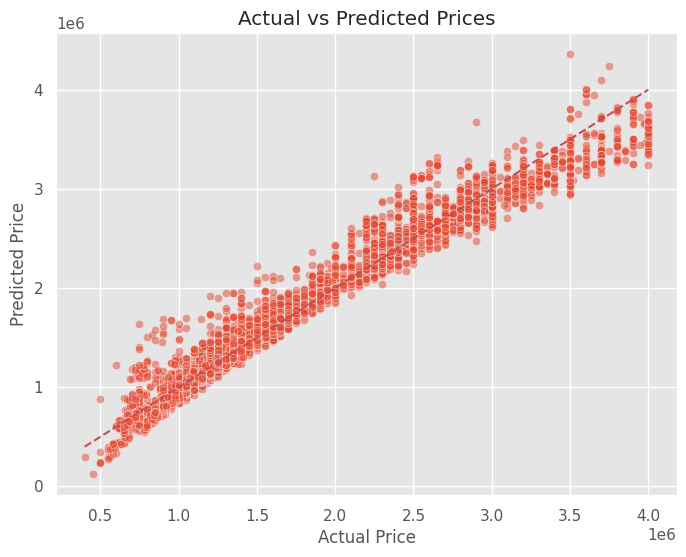

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # خط 45 درجة
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()


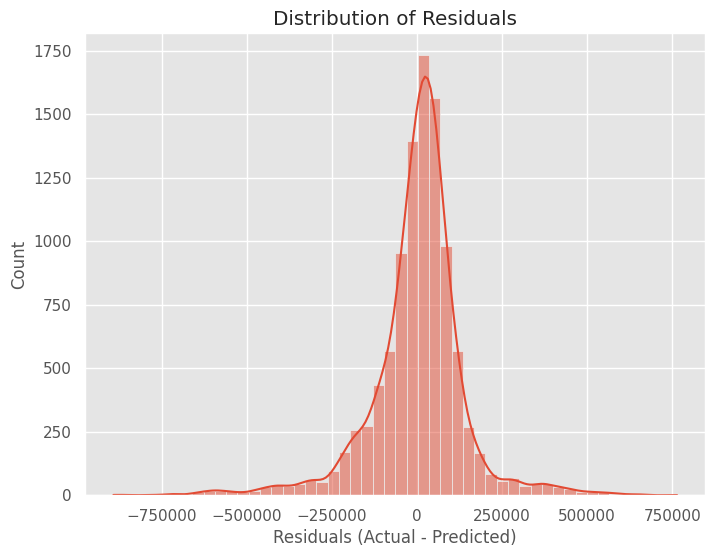

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("Distribution of Residuals")
plt.show()


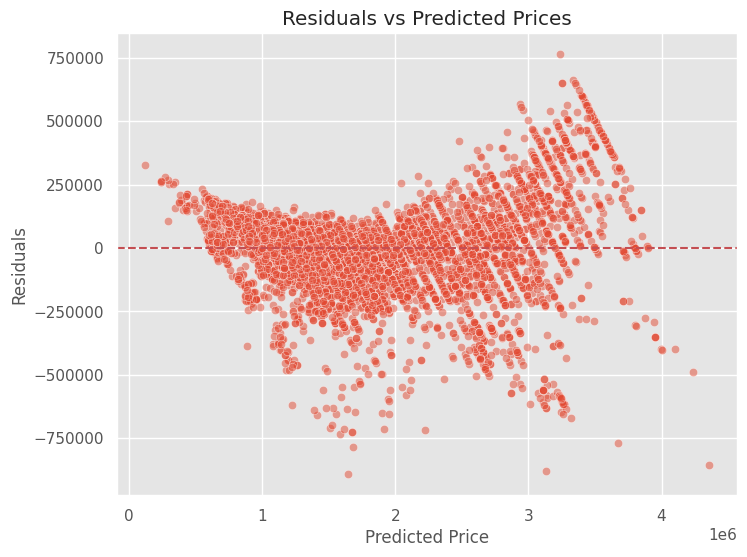

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Prices")
plt.show()


XGBoost Model Evaluation:
R² Score   : 0.998
MAE        : 22,693 ريال
RMSE       : 35,882 ريال


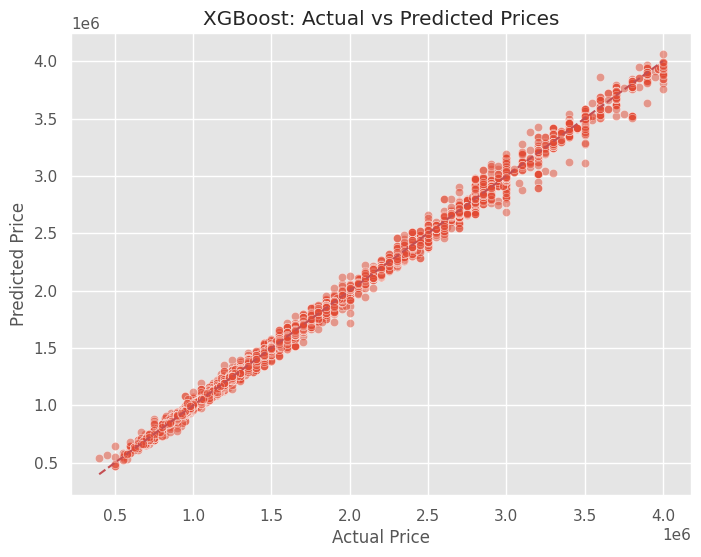

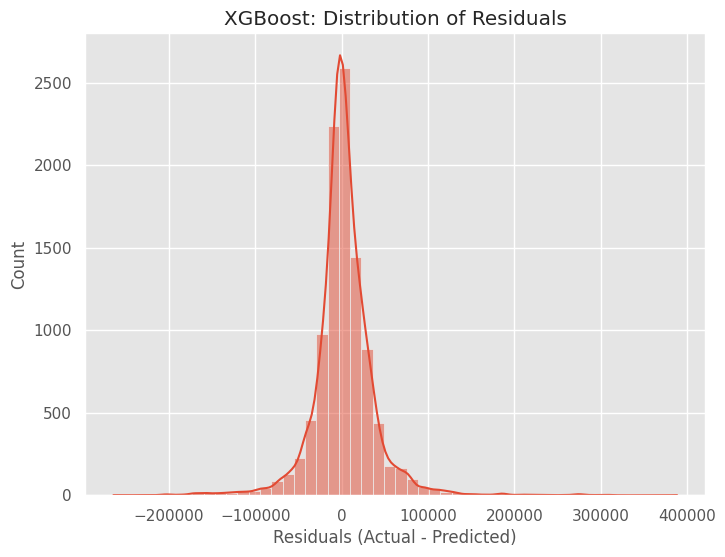

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# إنشاء نموذج XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # regression objective
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# تدريب النموذج
xgb_model.fit(X_train, y_train)

# التنبؤ على بيانات الاختبار
y_pred_xgb = xgb_model.predict(X_test)

# تقييم النموذج
r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Model Evaluation:")
print(f"R² Score   : {r2:.3f}")
print(f"MAE        : {mae:,.0f} ريال")
print(f"RMSE       : {rmse:,.0f} ريال")

# رسم Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted Prices")
plt.show()

# رسم residuals distribution
residuals = y_test - y_pred_xgb
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("XGBoost: Distribution of Residuals")
plt.show()


In [ ]:
# تقييم على بيانات التدريب
y_train_pred = xgb_model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

print(f"Train R²: {r2_train:.3f}")
print(f"Train MAE: {mae_train:,.0f}")

# نتائج الاختبار (موجودة عندك سابقاً)
print(f"Test R² : {r2:.3f}")
print(f"Test MAE : {mae:,.0f}")


Train R²: 0.999
Train MAE: 18,629
Test R² : 0.998
Test MAE : 22,693


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007943 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 783
[LightGBM] [Info] Number of data points in the train set: 23910, number of used features: 34
[LightGBM] [Info] Start training from score 1658833.542702
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

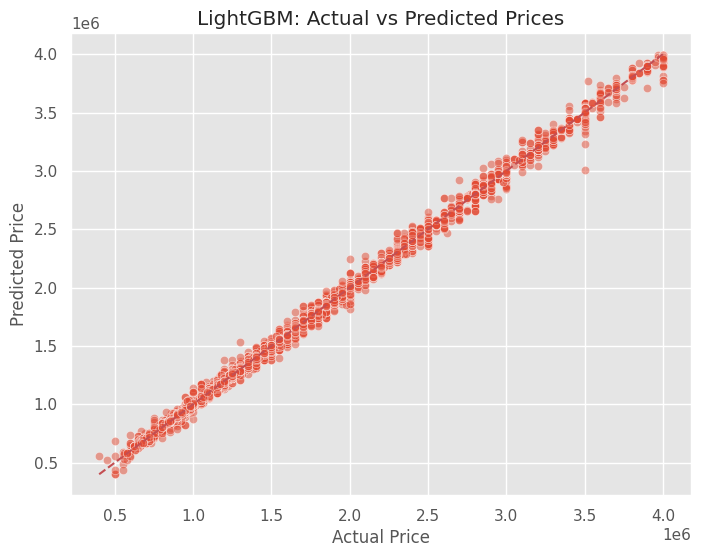

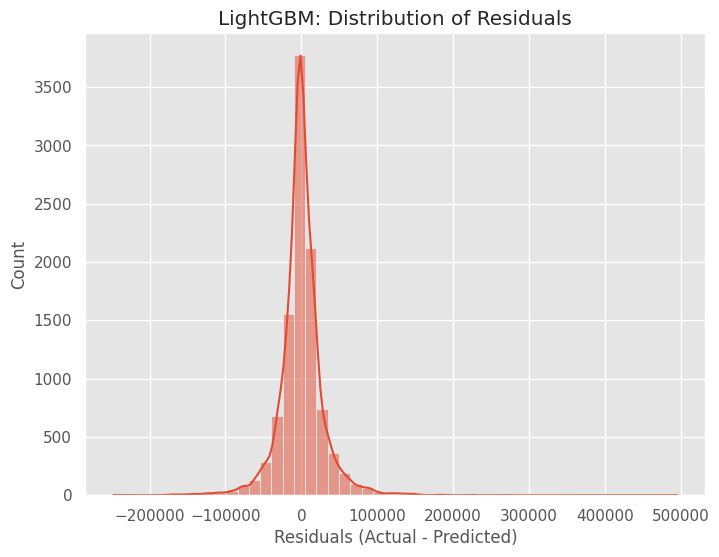

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# إنشاء نموذج LightGBM Regressor
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# تدريب النموذج
lgb_model.fit(X_train, y_train)

# التنبؤ على بيانات الاختبار
y_pred_lgb = lgb_model.predict(X_test)

# تقييم النموذج
r2 = r2_score(y_test, y_pred_lgb)
mae = mean_absolute_error(y_test, y_pred_lgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

print("LightGBM Model Evaluation:")
print(f"R² Score   : {r2:.3f}")
print(f"MAE        : {mae:,.0f} ريال")
print(f"RMSE       : {rmse:,.0f} ريال")

# رسم Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_lgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("LightGBM: Actual vs Predicted Prices")
plt.show()

# رسم residuals distribution
residuals = y_test - y_pred_lgb
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("LightGBM: Distribution of Residuals")
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# تحضير النماذج
models = {
    'Linear Regression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

# تعريف دوال التقييم لاستخدامها في cross_val_score
def mae_scorer(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# تخزين النتائج
results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")

    # R2 (مقياس تناسب)
    r2_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')

    # MAE (خطأ متوسط مطلق)
    mae_scores = -cross_val_score(model, X_train, y_train, cv=kf, scoring=make_scorer(mean_absolute_error))

    # RMSE (الجذر التربيعي لمتوسط الخطأ التربيعي)
    rmse_scores = -cross_val_score(model, X_train, y_train, cv=kf, scoring=make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))))

    results[name] = {
        'R2 Mean': np.mean(r2_scores),
        'R2 Std': np.std(r2_scores),
        'MAE Mean': np.mean(mae_scores),
        'MAE Std': np.std(mae_scores),
        'RMSE Mean': np.mean(rmse_scores),
        'RMSE Std': np.std(rmse_scores)
    }

# طباعة النتائج النهائية
for name, metrics in results.items():
    print(f"\nModel: {name}")
    print(f"Average R²: {metrics['R2 Mean']:.4f} ± {metrics['R2 Std']:.4f}")


    print(f"Average MAE: {abs(metrics['MAE Mean']):.0f} ± {metrics['MAE Std']:.0f}")
print(f"Average RMSE: {abs(metrics['RMSE Mean']):.0f} ± {metrics['RMSE Std']:.0f}")



Evaluating Linear Regression...
Evaluating XGBoost...
Evaluating Random Forest...

Model: Linear Regression
Average R²: 0.9630 ± 0.0021
Average MAE: 92734 ± 1956

Model: XGBoost
Average R²: 0.9986 ± 0.0002
Average MAE: 14169 ± 391

Model: Random Forest
Average R²: 0.9986 ± 0.0004
Average MAE: 7271 ± 574
Average RMSE: 27604 ± 4044
